In [636]:
import pandas as pd

day_1_prices = pd.read_csv("../../data/round_4/prices_round_4_day_1.csv", sep=";")
day_2_prices = pd.read_csv("../../data/round_4/prices_round_4_day_2.csv", sep=";")
day_3_prices = pd.read_csv("../../data/round_4/prices_round_4_day_3.csv", sep=";")

day_1_trades = pd.read_csv("../../data/round_4/trades_round_4_day_1.csv", sep=";")
day_2_trades = pd.read_csv("../../data/round_4/trades_round_4_day_2.csv", sep=";")
day_3_trades = pd.read_csv("../../data/round_4/trades_round_4_day_3.csv", sep=";")

day_1_prices["day"] = 1
day_2_prices["day"] = 2
day_3_prices["day"] = 3

day_1_trades["day"] = 1
day_2_trades["day"] = 2
day_3_trades["day"] = 3

all_prices = pd.concat(
    [day_1_prices, day_2_prices, day_3_prices],
    ignore_index=True
)

all_trades = pd.concat(
    [day_1_trades, day_2_trades, day_3_trades],
    ignore_index=True
)

all_prices["global_time"] = all_prices["day"] * 1_000_000 + all_prices["timestamp"]
all_trades["global_time"] = all_trades["day"] * 1_000_000 + all_trades["timestamp"]

DELTA_ONE_PRODUCTS = [
    "HYDROGEL_PACK",
    "VELVETFRUIT_EXTRACT",
]

VOUCHERS = [
    "VEV_4000",
    "VEV_4500",
    "VEV_5000",
    "VEV_5100",
    "VEV_5200",
    "VEV_5300",
    "VEV_5400",
    "VEV_5500",
    "VEV_6000",
    "VEV_6500",
]

ALL_PRODUCTS = DELTA_ONE_PRODUCTS + VOUCHERS

prices_by_product = {
    product: all_prices[all_prices["product"] == product].copy()
    for product in ALL_PRODUCTS
}

trades_by_product = {
    product: all_trades[all_trades["symbol"] == product].copy()
    for product in ALL_PRODUCTS
}

hydro_prices = prices_by_product["HYDROGEL_PACK"]
fruit_prices = prices_by_product["VELVETFRUIT_EXTRACT"]

hydro_trades = trades_by_product["HYDROGEL_PACK"]
fruit_trades = trades_by_product["VELVETFRUIT_EXTRACT"]

vev_4000_prices = prices_by_product["VEV_4000"]
vev_4500_prices = prices_by_product["VEV_4500"]
vev_5000_prices = prices_by_product["VEV_5000"]
vev_5100_prices = prices_by_product["VEV_5100"]
vev_5200_prices = prices_by_product["VEV_5200"]
vev_5300_prices = prices_by_product["VEV_5300"]
vev_5400_prices = prices_by_product["VEV_5400"]
vev_5500_prices = prices_by_product["VEV_5500"]
vev_6000_prices = prices_by_product["VEV_6000"]
vev_6500_prices = prices_by_product["VEV_6500"]

vev_4000_trades = trades_by_product["VEV_4000"]
vev_4500_trades = trades_by_product["VEV_4500"]
vev_5000_trades = trades_by_product["VEV_5000"]
vev_5100_trades = trades_by_product["VEV_5100"]
vev_5200_trades = trades_by_product["VEV_5200"]
vev_5300_trades = trades_by_product["VEV_5300"]
vev_5400_trades = trades_by_product["VEV_5400"]
vev_5500_trades = trades_by_product["VEV_5500"]
vev_6000_trades = trades_by_product["VEV_6000"]
vev_6500_trades = trades_by_product["VEV_6500"]

voucher_prices = all_prices[all_prices["product"].isin(VOUCHERS)].copy()
voucher_trades = all_trades[all_trades["symbol"].isin(VOUCHERS)].copy()

voucher_prices["strike"] = voucher_prices["product"].str.replace("VEV_", "").astype(int)
voucher_trades["strike"] = voucher_trades["symbol"].str.replace("VEV_", "").astype(int)

all_prices["tte"] = 4
all_trades["tte"] = 4

voucher_prices["tte"] = 4
voucher_trades["tte"] = 4

In [637]:
fruit = fruit_prices[["global_time", "mid_price"]].rename(columns={"mid_price": "spot"})

In [638]:
voucher_prices["mid_price"] = (voucher_prices["bid_price_1"] + 
                                voucher_prices["ask_price_1"]) / 2

In [639]:
voucher_ivs = voucher_prices.drop(columns=['bid_price_1', 
                                           'bid_volume_1',
                                           'bid_price_2',
                                           'bid_volume_2',
                                           'bid_price_3',
                                           'bid_volume_3',
                                           'ask_price_1',
                                           'ask_volume_1',
                                           'ask_price_2',
                                           'ask_volume_2',
                                           'ask_price_3',
                                           'ask_volume_3',
                                           'profit_and_loss'])

voucher_ivs["strike"] = voucher_ivs["product"].str.split("_").str[1].astype(int)

In [640]:
voucher_ivs = voucher_ivs.merge(fruit, on="global_time", how="left")

In [641]:
voucher_ivs

,day,timestamp,product,mid_price,global_time,strike,tte,spot
0,1,0,VEV_6000,0.5,1000000,6000,4,5245.0
1,1,0,VEV_5000,251.0,1000000,5000,4,5245.0
2,1,0,VEV_6500,0.5,1000000,6500,4,5245.0
3,1,0,VEV_5300,47.0,1000000,5300,4,5245.0
4,1,0,VEV_5400,16.5,1000000,5400,4,5245.0
...,...,...,...,...,...,...,...,...
299995,3,999900,VEV_4000,1232.0,3999900,4000,4,5232.0
299996,3,999900,VEV_5100,141.5,3999900,5100,4,5232.0
299997,3,999900,VEV_5200,70.0,3999900,5200,4,5232.0
299998,3,999900,VEV_5000,234.0,3999900,5000,4,5232.0


In [642]:
import numpy as np

voucher_ivs["moneyness"] = np.log(voucher_ivs["spot"] / voucher_ivs["strike"])

In [643]:
from math import erf, sqrt, log
from typing import Optional

VOL_FLOOR = 0.01
VOL_CAP = 3.00

def normal_cdf(x: float):
    return 0.5 * (1 + erf(x / sqrt(2.0)))

def black_scholes_call(spot: float, strike: float, tte_days: float, volatility: float):
    intrinsic = max(0.0, spot - strike)

    if spot <=0 or strike <= 0 or tte_days <= 0 or volatility <= 0:
        return intrinsic
    
    t = max(tte_days / 365, 1e-6)
    sigma_sqrt_t = volatility * sqrt(t)

    if sigma_sqrt_t <= 1e-9:
        return intrinsic
    
    d1 = (log(spot / strike) + 0.5 * volatility ** 2 * t) / sigma_sqrt_t
    d2 = d1 - sigma_sqrt_t

    return max(intrinsic, spot * normal_cdf(d1) - strike * normal_cdf(d2))

def implied_call_volatility(spot, strike, tte_days, option_price):
    intrinsic = max(0.0, spot - strike)

    if (
        spot <= 0
        or strike <= 0
        or tte_days <= 0
        or option_price <= intrinsic + 0.05
    ):
        return None

    lower = VOL_FLOOR
    upper = VOL_CAP

    # Check if price is even reachable inside bounds
    low_price = black_scholes_call(spot, strike, tte_days, lower)
    high_price = black_scholes_call(spot, strike, tte_days, upper)

    if option_price < low_price or option_price > high_price:
        return None

    for _ in range(35):
        mid = (lower + upper) / 2
        model_price = black_scholes_call(spot, strike, tte_days, mid)

        if model_price < option_price:
            lower = mid
        else:
            upper = mid

    return (lower + upper) / 2


In [644]:
voucher_ivs["implied_vol"] = voucher_ivs.apply(
    lambda row: implied_call_volatility(
        spot=row["spot"],
        strike=row["strike"],
        tte_days=row["tte"],
        option_price=row["mid_price"]
    ),
    axis=1
)

In [645]:
voucher_ivs.head(20)

,day,timestamp,product,mid_price,global_time,strike,tte,spot,moneyness,implied_vol
0,1,0,VEV_6000,0.5,1000000,6000,4,5245.0,-0.134484,0.502996
1,1,0,VEV_5000,251.0,1000000,5000,4,5245.0,0.047837,0.321141
2,1,0,VEV_6500,0.5,1000000,6500,4,5245.0,-0.214527,0.760317
3,1,0,VEV_5300,47.0,1000000,5300,4,5245.0,-0.010432,0.323107
4,1,0,VEV_5400,16.5,1000000,5400,4,5245.0,-0.029124,0.303717
5,1,0,VEV_4000,1245.0,1000000,4000,4,5245.0,0.270981,NaN
6,1,0,VEV_5100,165.0,1000000,5100,4,5245.0,0.028035,0.323240
7,1,0,VEV_5200,95.5,1000000,5200,4,5245.0,0.008617,0.324324
8,1,0,VEV_5500,7.5,1000000,5500,4,5245.0,-0.047473,0.333418
9,1,0,VEV_4500,745.0,1000000,4500,4,5245.0,0.153198,NaN


In [646]:
cleaned_ivs = voucher_ivs.dropna(subset=["implied_vol", "moneyness"])

In [647]:
cleaned_ivs["global_time1"] = cleaned_ivs["global_time"]

KeyError: 'fitted_iv'

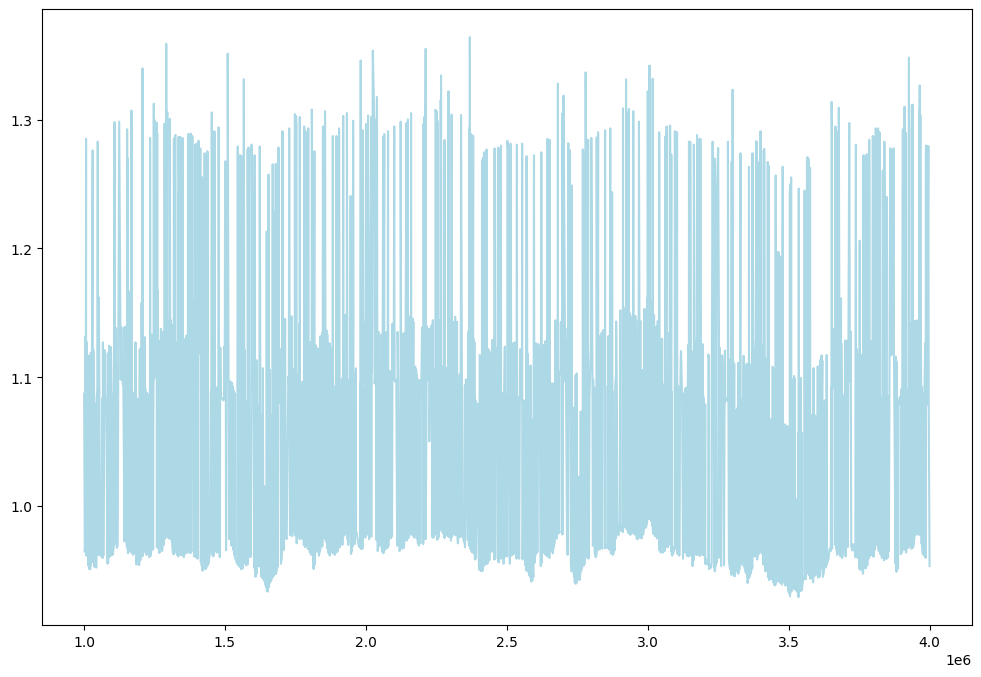

In [648]:
import matplotlib.pyplot as plt

vev_4000 = cleaned_ivs[cleaned_ivs["product"] == "VEV_4000"]

plt.figure(figsize=(12, 8))
plt.plot(vev_4000["global_time1"], vev_4000["implied_vol"], lw=1.5, color="lightblue")
plt.plot(vev_4000["global_time1"], vev_4000["fitted_iv"], lw=1.5, color="darkgreen")

In [ ]:
def fit_smile(group):
    group = group.copy()

    valid = group.dropna(subset=["implied_vol", "moneyness"])

    if len(valid) < 4:
        group["fitted_iv"] = np.nan
        group["iv_deviation"] = np.nan
        return group

    coeffs = np.polyfit(valid["moneyness"], valid["implied_vol"], 2)

    group["fitted_iv"] = np.polyval(coeffs, group["moneyness"])
    group["iv_deviation"] = group["implied_vol"] - group["fitted_iv"]

    return group

cleaned_ivs = (
    cleaned_ivs
    .groupby("global_time", group_keys=False)
    .apply(fit_smile)
    .reset_index(drop=False)
)

In [ ]:
cleaned_ivs.head(3)

,index,day,timestamp,product,mid_price,strike,tte,spot,moneyness,implied_vol,global_time1,fitted_iv,iv_deviation
0,0,1,0,VEV_6000,0.5,6000,4,5245.0,-0.134484,0.502996,1000000,0.494510,0.008486
1,1,1,0,VEV_5000,251.0,5000,4,5245.0,0.047837,0.321141,1000000,0.329127,-0.007986
2,2,1,0,VEV_6500,0.5,6500,4,5245.0,-0.214527,0.760317,1000000,0.762797,-0.002480


In [ ]:
threshold = 0.02

cleaned_ivs["signal"] = 0
cleaned_ivs.loc[cleaned_ivs["iv_deviation"] <= -threshold, "target_position"] = 1
cleaned_ivs.loc[cleaned_ivs["iv_deviation"] >= threshold, "target_position"] = -1

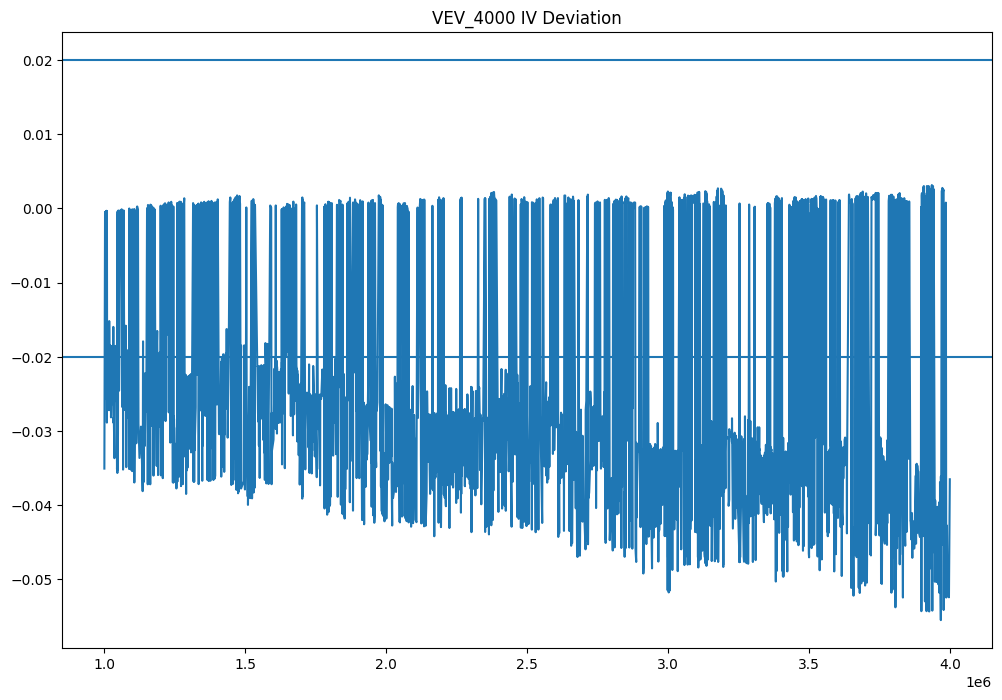

In [ ]:
import matplotlib.pyplot as plt

vev_4000 = cleaned_ivs[cleaned_ivs["product"] == "VEV_4000"]

plt.figure(figsize=(12, 8))
plt.plot(vev_4000["global_time1"], vev_4000["iv_deviation"])
plt.axhline(0.02)
plt.axhline(-0.02)
plt.title("VEV_4000 IV Deviation")
plt.show()

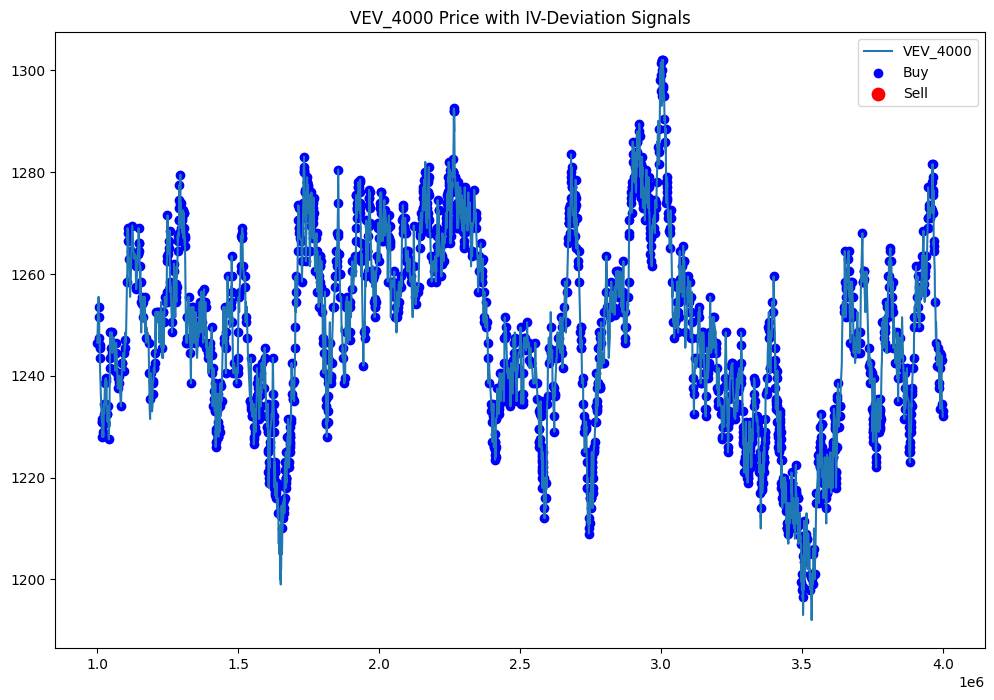

In [ ]:
product = "VEV_4000"
df = cleaned_ivs[cleaned_ivs["product"] == product].copy()

buy = df["target_position"] == 1
sell = df["target_position"] == -1

plt.figure(figsize=(12, 8))
plt.plot(df["global_time1"], df["mid_price"], label=product)

plt.scatter(df.loc[buy, "global_time1"], df.loc[buy, "mid_price"], 
            color="blue", label="Buy")
plt.scatter(df.loc[sell, "global_time1"], df.loc[sell, "mid_price"], 
            color="red", s=80, label="Sell", zorder=5)

plt.legend()
plt.title(f"{product} Price with IV-Deviation Signals")
plt.show()

In [ ]:
cleaned_ivs.groupby("product")["target_position"].value_counts()

product   target_position
VEV_4000   1.0                2067
VEV_4500  -1.0                2139
VEV_5000   1.0                4475
VEV_5100   1.0                 725
          -1.0                   7
VEV_5200  -1.0                 183
           1.0                   2
VEV_5300  -1.0                 489
VEV_5400   1.0               12075
VEV_5500   1.0                8189
VEV_6000  -1.0               17289
VEV_6500   1.0                1925
Name: count, dtype: int64

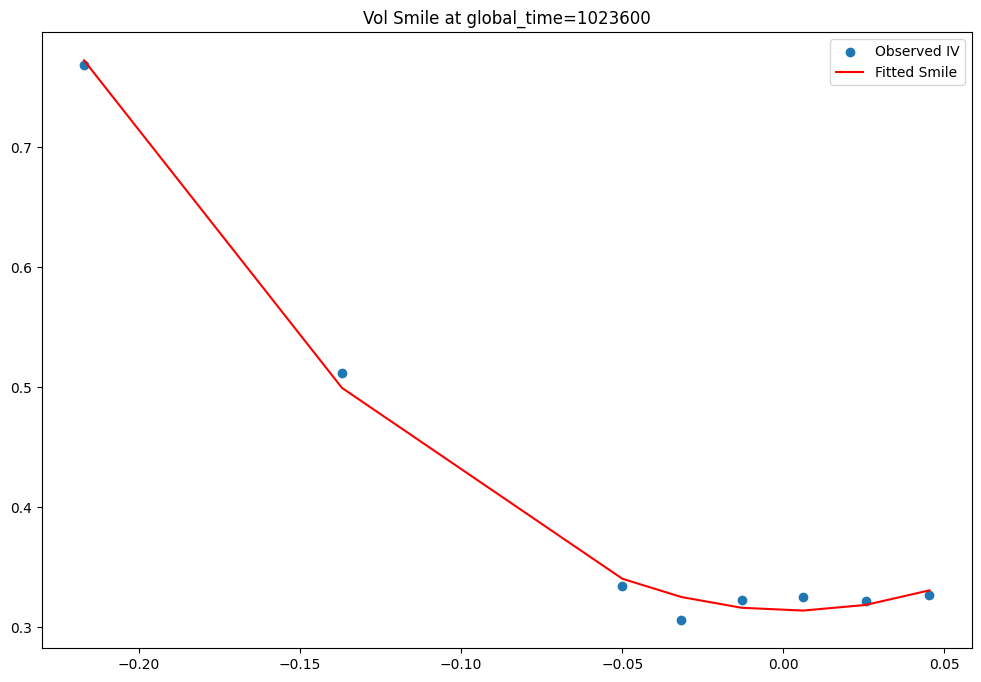

In [ ]:
t = cleaned_ivs["global_time1"].iloc[2000]

sample = cleaned_ivs[cleaned_ivs["global_time1"] == t].copy()
sample = sample.sort_values("moneyness")

plt.figure(figsize=(12, 8))

plt.scatter(sample["moneyness"], sample["implied_vol"], label="Observed IV")

plt.plot(
    sample["moneyness"],
    sample["fitted_iv"],
    color="red",
    label="Fitted Smile"
)

plt.legend()
plt.title(f"Vol Smile at global_time={t}")
plt.show()